# Week 1 Lab – Linear Regression with One Feature (Vectorized)

In this lab we will work with the same simple supervised learning problem from the first notebook:

- Our data consists of pairs $(x^{(i)}, y^{(i)})$, where $x^{(i)}$ is one feature and $y^{(i)}$ is the target.
- We will use a **linear regression model** with one feature.
- We will measure how good the model is using a **cost function** based on mean squared error.
- We will train the model with **gradient descent**.
- This notebook uses **NumPy vectorization** to compute predictions, costs, and gradients.

If vectorization is new to you, start with the previous notebook: `02-week1_vectorization.ipynb`.



## 0. Theory Refresher

### 0.1 Linear Regression (One Feature)

We assume there is (approximately) a linear relationship between the input $x$ and the output $y$.  
Our model (or hypothesis) is a function that depends on the parameters $w$ and $b$:

$$
f_{w,b}(x) = wx + b
$$

- $w$ is the **slope**: how much $f_{w,b}(x)$ changes when $x$ increases by 1.
- $b$ is the **intercept**: the value of $f_{w,b}(x)$ when $x = 0$.
- For a dataset with $m$ examples, we write the $i$-th example as $(x^{(i)}, y^{(i)})$.  
  The prediction for that example is:
  $$
  \hat{y}^{(i)} = f_{w,b}(x^{(i)}) = w x^{(i)} + b
  $$



### 0.2 Cost Function (Mean Squared Error)

We need a way to measure how well a particular line (given by $w$ and $b$) fits the data.

We use the **mean squared error (MSE)** cost function:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( \hat{y}^{(i)} - y^{(i)} \big)^2
       = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$

- The term $(\hat{y}^{(i)} - y^{(i)})$ is the **error** for example $i$.
- We square the error so that positive and negative errors do not cancel out, and to penalize large errors more.
- The factor $\frac{1}{2m}$ is for mathematical convenience when taking derivatives.

Our goal is to find values of $w$ and $b$ that **minimize** $J(w,b)$.



### 0.3 Gradient Descent

To minimize $J(w,b)$, we use **gradient descent**.  
The idea is to start with some initial $(w,b)$ and repeatedly update them in the direction that decreases the cost.

We compute the partial derivatives:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Given a **learning rate** $\alpha > 0$, we update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \qquad
b := b - \alpha \frac{\partial J}{\partial b}
$$

We repeat these updates many times. If $\alpha$ is chosen well, the cost $J(w,b)$ will decrease and $(w,b)$ will move toward values that fit the data.


## 1. Setup

In [128]:
# Install required libraries (run this once if needed)
%pip install numpy matplotlib



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


Matplotlib is building the font cache; this may take a moment.


## 2. Create a Simple Dataset

We will create a synthetic dataset that roughly follows this linear relationship:

$$
y \approx 3x + 2 + \text{noise}
$$

Each point is a pair $(x^{(i)}, y^{(i)})$ with **one feature** $x^{(i)}$.

This time, we create the dataset directly with NumPy arrays. This is the vectorized version of the dataset style used in the first notebook.


In [2]:
# m is the number of training examples.
m = 50

# These are the true values used to create the example data.
# Gradient descent will try to recover values close to these.
true_w = 3.0
true_b = 2.0

# This controls how noisy the data is.
# Try values like 0, 2, 6, or 10.
noise_factor = 8.0

# Create m values evenly spaced between 0 and 10.
# This is the NumPy version of the loop we used in the non-vectorized notebook.
x = np.linspace(0, 10, m)

# Create random noise for all m examples at once.
rng = np.random.default_rng(0)
noise = rng.uniform(-1, 1, size=m) * noise_factor

# Create all y values at once using vectorized arithmetic.
y = true_w * x + true_b + noise

print(f"Number of examples m = {m}")
print("First 5 x values:", x[:5])
print("First 5 y values:", y[:5])


Number of examples m = 50
First 5 x values: [0.     0.2041 0.4082 0.6122 0.8163]
First 5 y values: [ 4.1914 -1.0712 -4.1199 -3.8988  9.4613]


### 2.1 Visualize the Data

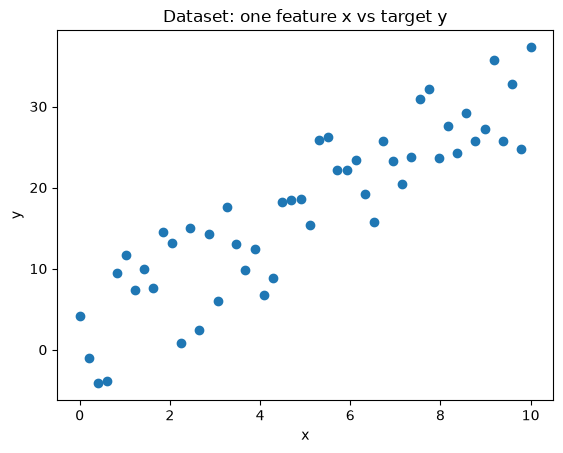

In [3]:
# Create a new empty figure.
plt.figure()

# Draw one point for each pair (x[i], y[i]).
plt.scatter(x, y)

# Add labels and a title so the plot is easy to read.
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset: one feature x vs target y")

# Display the plot.
plt.show()



## 3. Linear Regression Model with One Feature

We use the model (hypothesis function):

$$
f_{w,b}(x^{(i)}) = w x^{(i)} + b
$$

where:
- $w$ is the slope,
- $b$ is the intercept.


In [4]:
def predict(x, w, b):
    """Compute predicted y values using the vectorized model f_{w,b}(x) = w*x + b."""
    # x is a NumPy array, so this single line computes one prediction per x value.
    return w * x + b


w_test = 0.0
b_test = 0.0

y_hat_test = predict(x, w_test, b_test)
print("First 5 predictions with w=0, b=0:", y_hat_test[:5])


First 5 predictions with w=0, b=0: [0. 0. 0. 0. 0.]



## 4. Cost Function $J(w,b)$

We define the **mean squared error** cost function:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$

This measures how well the model $f_{w,b}(x) = w x + b$ fits the data.


In [5]:
def compute_cost(x, y, w, b):
    """Compute the cost J(w,b) using NumPy vectorization."""
    m = x.shape[0]

    # Step 1: compute all predictions at once.
    y_hat = w * x + b

    # Step 2: compute all errors at once.
    errors = y_hat - y

    # Step 3: square all errors, sum them, and divide by 2m.
    cost = np.sum(errors ** 2) / (2 * m)

    return cost


print("Cost with w=0, b=0:", compute_cost(x, y, w_test, b_test))


Cost with w=0, b=0: 203.1726582311442


### 4.1 Visualize the Cost Function as a Surface

We can visualize how $J(w,b)$ changes as we vary $w$ and $b$.

In the non-vectorized notebook, we built the surface using lists and nested loops. Here we use NumPy's `meshgrid` to create a grid of possible `w` and `b` values.

The grid is intentionally moderate in size so the cell runs quickly while still showing the shape of the cost surface.


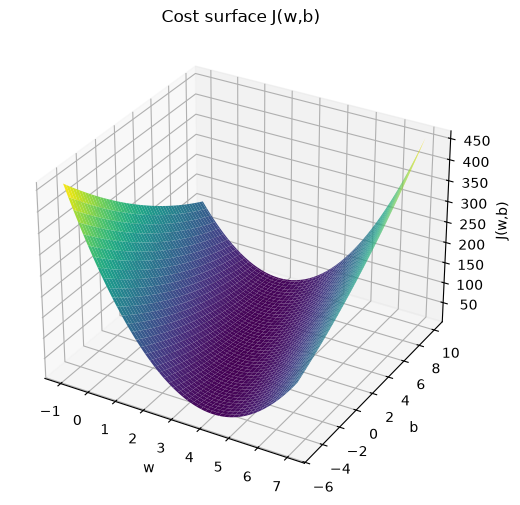

In [6]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Choose ranges of values to test for w and b.
# 100 values per axis gives a 100 x 100 surface.
w_values = np.linspace(-1.0, 7.0, 100)
b_values = np.linspace(-5.0, 10.0, 100)

# np.meshgrid creates every combination of w and b values.
# W and B are both 2D arrays with shape (100, 100).
W, B = np.meshgrid(w_values, b_values)

# J_vals will store the cost for each pair (W[row, col], B[row, col]).
J_vals = np.zeros_like(W)

# For each training example, compute its error for every (w, b) pair at once.
# This keeps the code vectorized over the surface grid.
for i in range(m):
    predictions_for_example = W * x[i] + B
    errors_for_example = predictions_for_example - y[i]
    J_vals = J_vals + errors_for_example ** 2

J_vals = J_vals / (2 * m)

# Create the 3D plot.
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0, antialiased=True)
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.set_title("Cost surface J(w,b)")
plt.show()



## 5. Gradient Descent

We use **gradient descent** with the update rules:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}, \quad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \quad
b := b - \alpha \frac{\partial J}{\partial b}
$$


In [7]:
def compute_gradients(x, y, w, b):
    """Compute dJ/dw and dJ/db using NumPy vectorization."""
    m = x.shape[0]

    # Compute all predictions and all errors at once.
    y_hat = w * x + b
    errors = y_hat - y

    # errors * x computes each example's contribution to dJ/dw.
    dj_dw = np.sum(errors * x) / m

    # The derivative with respect to b is the average error.
    dj_db = np.sum(errors) / m

    return dj_dw, dj_db


dj_dw_test, dj_db_test = compute_gradients(x, y, w_test, b_test)
print("Gradients at w=0, b=0:", dj_dw_test, dj_db_test)


Gradients at w=0, b=0: -113.62644719828276 -17.429370430304534


### 5.1 Implement the Gradient Descent Loop

In [9]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iterations):
    """Run gradient descent using vectorized cost and gradient computations."""
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        # Compute the vectorized gradients.
        dj_dw, dj_db = compute_gradients(x, y, w, b)

        # Update both parameters.
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Save the cost so we can plot learning progress later.
        cost = compute_cost(x, y, w, b)
        history.append((i, cost))

        if i % max(1, (num_iterations // 10)) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")

    return w, b, history


alpha = 0.01
num_iterations = 14000

w_init = 0.0
b_init = 0.0

w_learned, b_learned, history = gradient_descent(x, y, w_init, b_init, alpha, num_iterations)

print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)


Iteration    0: w= 1.1363, b= 0.1743, cost= 93.7684
Iteration 1400: w= 3.0602, b= 2.1159, cost= 10.8612
Iteration 2800: w= 3.0532, b= 2.1632, cost= 10.8609
Iteration 4200: w= 3.0529, b= 2.1646, cost= 10.8609
Iteration 5600: w= 3.0529, b= 2.1647, cost= 10.8609
Iteration 7000: w= 3.0529, b= 2.1647, cost= 10.8609
Iteration 8400: w= 3.0529, b= 2.1647, cost= 10.8609
Iteration 9800: w= 3.0529, b= 2.1647, cost= 10.8609
Iteration 11200: w= 3.0529, b= 2.1647, cost= 10.8609
Iteration 12600: w= 3.0529, b= 2.1647, cost= 10.8609

Learned parameters:
w = 3.0529415465676473
b = 2.164662697466275


### 5.2 Plot the Cost over Iterations

At the beginning of training, the cost may drop very quickly. This can make the full plot hard to read because the y-axis becomes too large.

To zoom in, change `start_iteration`. For example, use `start_iteration = 0` to see the full training history, or `start_iteration = 200` to focus on later convergence.


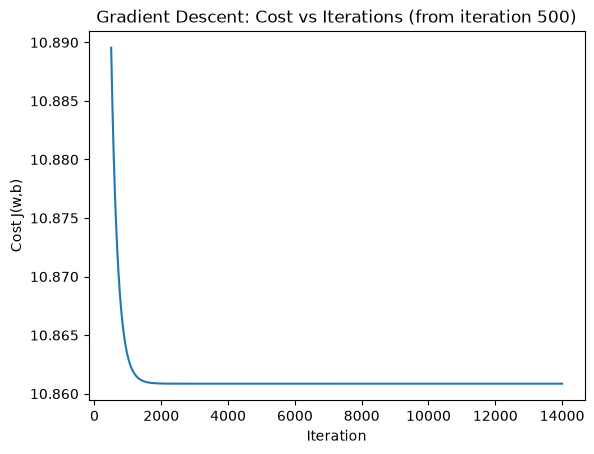

In [10]:
iterations = [it for it, c in history]
costs = [c for it, c in history]

# Change this value to zoom into the cost curve.
# Use 0 to show all iterations.
# Use 200, 500, or 1000 to skip the early high-cost region.
start_iteration = 500

# Find the first position in the history where the iteration is at least start_iteration.
start_index = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration:
        start_index = i
        break

fig, ax = plt.subplots()
ax.plot(iterations[start_index:], costs[start_index:])
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {start_iteration})")

# When the visible cost values are very close together, Matplotlib may use
# an offset such as +1.086e1 on the y-axis. That can look strange to students.
# This keeps the labels as the actual cost values.
ax.ticklabel_format(axis="y", style="plain", useOffset=False)

plt.show()


### 5.3 Visualize the Fitted Line

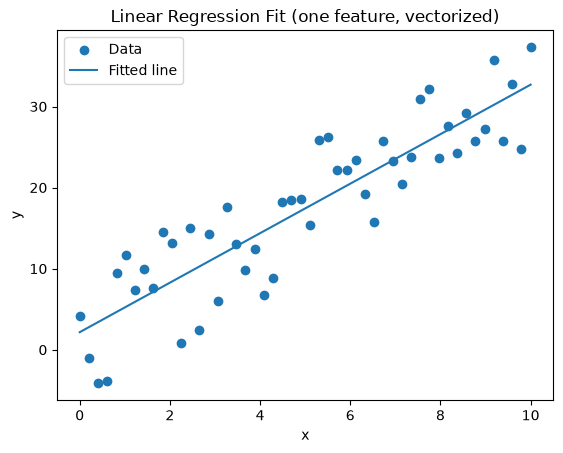

In [11]:
plt.figure()
plt.scatter(x, y, label="Data")

# predict is vectorized, so it computes all fitted-line y values at once.
y_pred = predict(x, w_learned, b_learned)

plt.plot(x, y_pred, label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit (one feature, vectorized)")
plt.legend()
plt.show()


## 6. Exercises (for You to Try)

1. **Change the learning rate $\alpha$**:
   - Try values like `0.001`, `0.01`, `0.1`.
   - What happens to the speed of convergence? Does the algorithm diverge for some values?

2. **Change the number of iterations**:
   - Try `num_iterations = 100`, `500`, `2000`.
   - How does the final cost change?

3. **Try different initial values** for `w_init` and `b_init`:
   - Does gradient descent still converge to similar values?

4. **Noise level**:
   - Go back to the cell where we define `noise_factor`.
   - Try values like `0`, `2`, `6`, or `10`.
   - How does the fitted line look with less or more noise?

5. **Vectorization check**:
   - In `compute_cost`, print the first five values of `errors`.
   - What does each value represent?

6. **Cost surface resolution**:
   - Change the number of points in `w_values` and `b_values` from `100` to `30` or `200`.
   - What changes in speed and visual smoothness?
